🎬 Simulation Mode Enabled
Using device: cuda


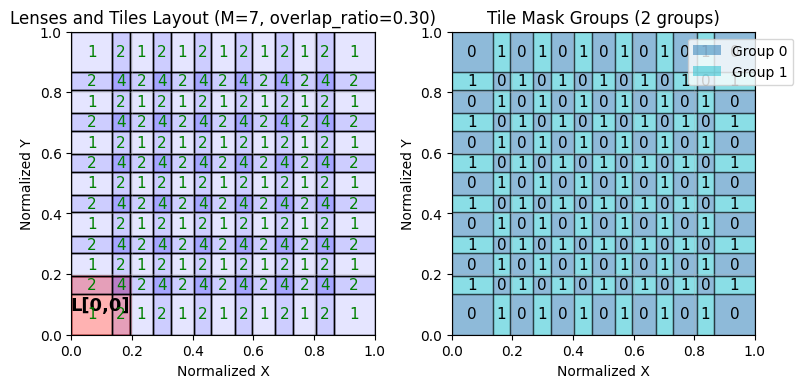


Tile Statistics:
Total tiles: 169
Grid dimensions: 13 x 13
Tiles per group: {0: 85, 1: 84}
Lens contribution distribution: {1: 49, 2: 84, 4: 36}
Starting optimization with 500 iterations...
Iter: 1/500 Focal_mse: 2136.0576 Eff_mean: 0.0010 Eff_std: 0.0002 Masked: 536.9639 Total: 2.6730e+03
Iter: 51/500 Focal_mse: 168.3123 Eff_mean: 0.6813 Eff_std: 0.0476 Masked: 195.7973 Total: 3.5777e+02
Iter: 101/500 Focal_mse: 52.2206 Eff_mean: 0.8040 Eff_std: 0.0196 Masked: 170.1411 Total: 2.1452e+02
Iter: 151/500 Focal_mse: 45.4547 Eff_mean: 0.8149 Eff_std: 0.0159 Masked: 167.6112 Total: 2.0508e+02
Iter: 201/500 Focal_mse: 44.1698 Eff_mean: 0.8172 Eff_std: 0.0156 Masked: 166.6936 Total: 2.0285e+02
Iter: 251/500 Focal_mse: 43.7337 Eff_mean: 0.8179 Eff_std: 0.0155 Masked: 166.1992 Total: 2.0191e+02
Iter: 301/500 Focal_mse: 43.5499 Eff_mean: 0.8182 Eff_std: 0.0153 Masked: 165.8865 Total: 2.0141e+02
Iter: 351/500 Focal_mse: 43.4524 Eff_mean: 0.8184 Eff_std: 0.0151 Masked: 165.6724 Total: 2.0109e+02
I

In [ ]:
import config
from optics_utils import process_parameters
from phase_generators import PhaseGenerator
from hardware import SLMManager

sim_mode = True
slm_manager = SLMManager(sim_mode=sim_mode)

# 默认参数字典 from config
test_raw_params = {}
test_raw_params.update(config.COMMON_DEFAULTS)
test_raw_params.update(config.OPTIMIZED_DEFAULTS)
test_raw_params.update(config.INTERNAL)

# 添加测试需要的基本信息 (这些信息之前GUI提供)
test_raw_params['shape'] = slm_manager.shape
test_raw_params['N'] = 980 # ROI尺寸

# 调用参数处理函数
final_params = process_parameters(test_raw_params)

# Optimization init
Optimizer = PhaseGenerator(final_params) 

# Run Optimize
Optimizer.generate(upsampling=2.0)

# Optimizer.generate(mode='fresnel')

if not sim_mode:
    slm_manager.upload(Optimizer.phase_8bit)


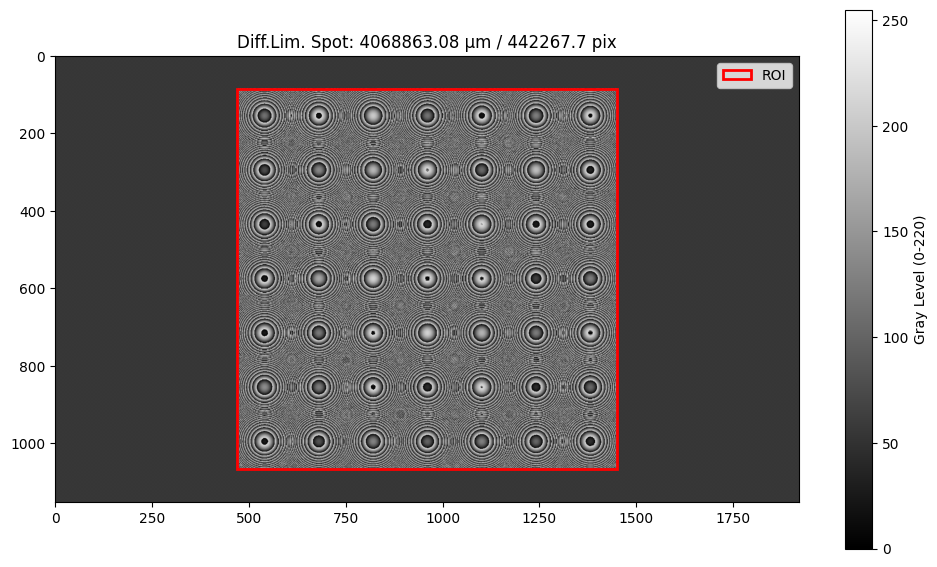

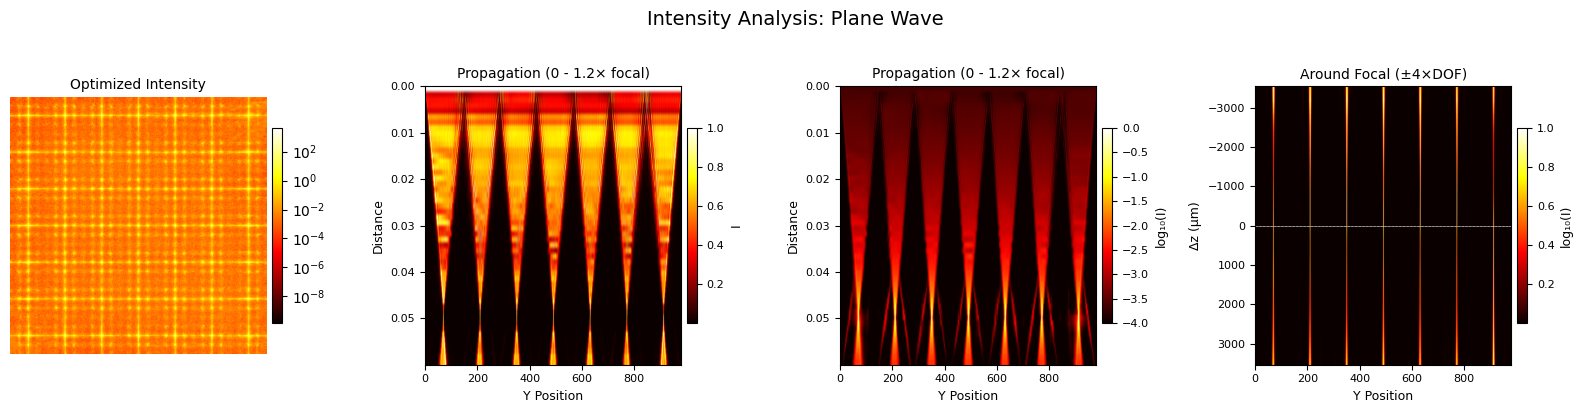

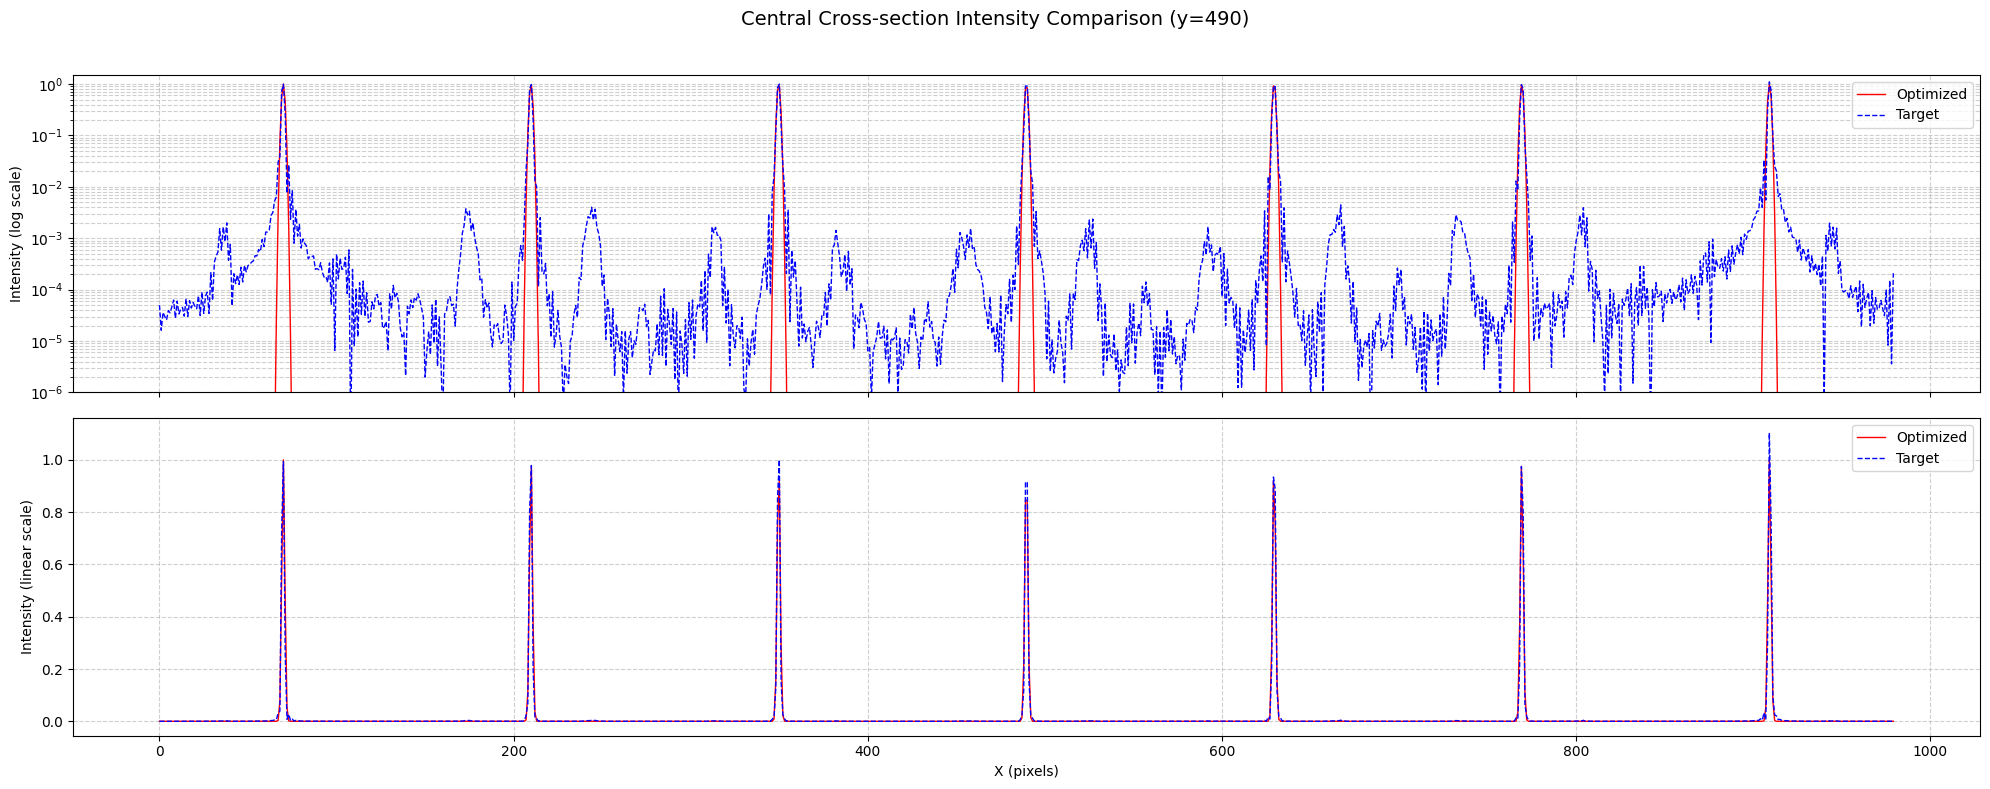

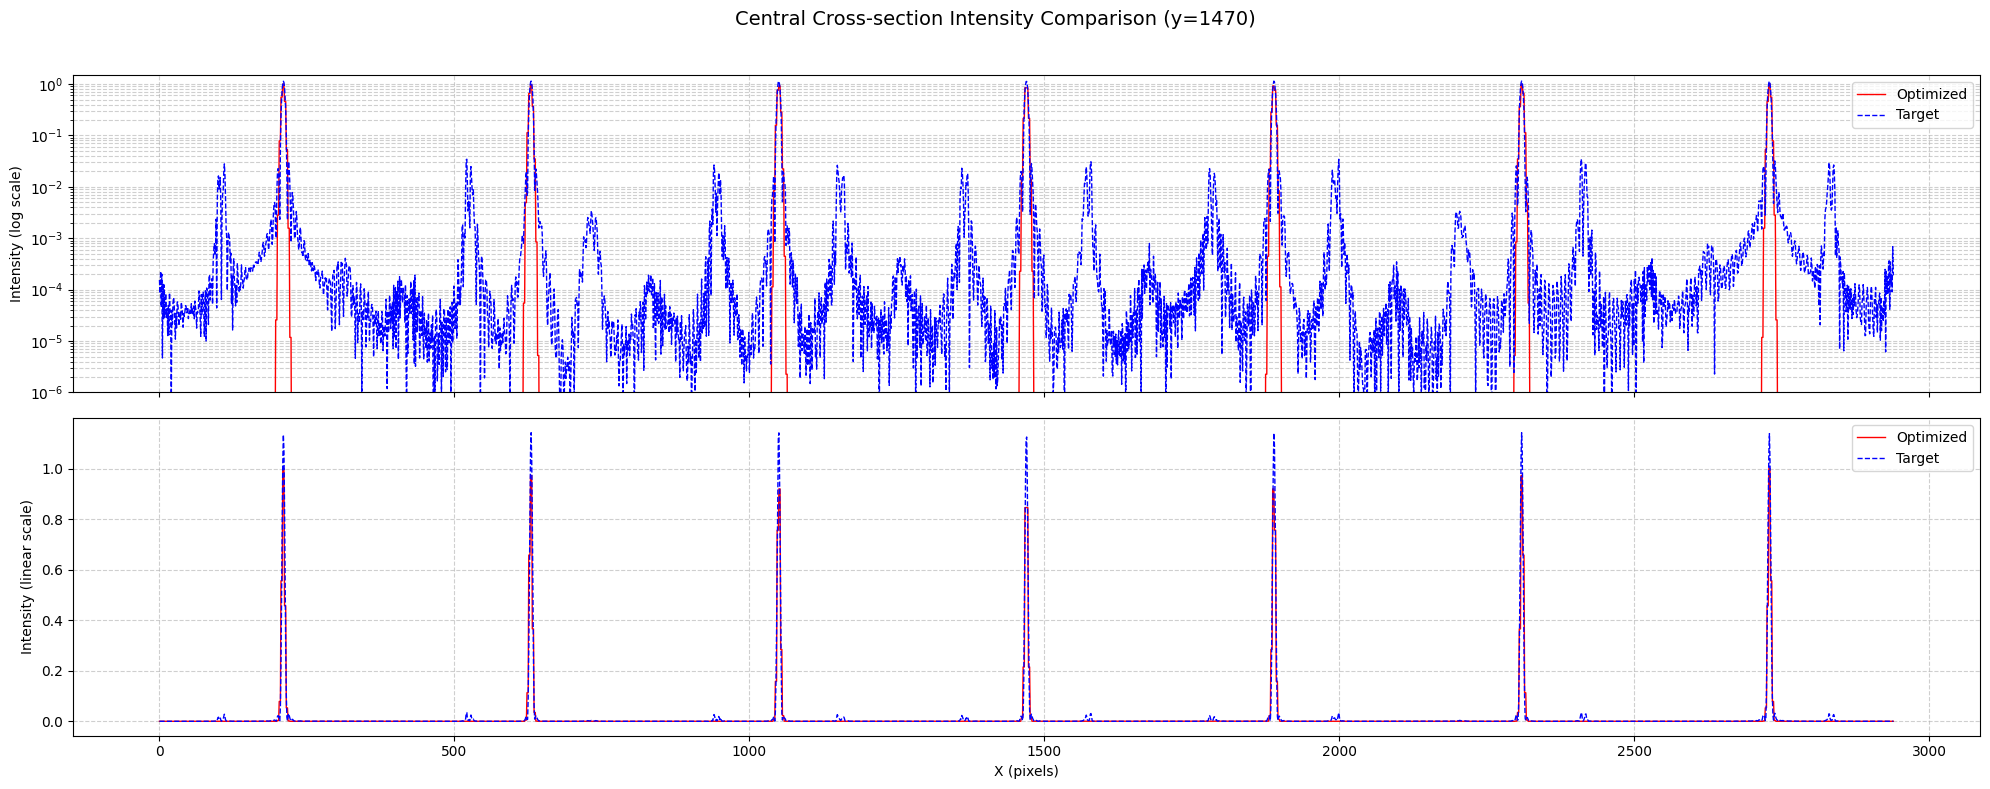

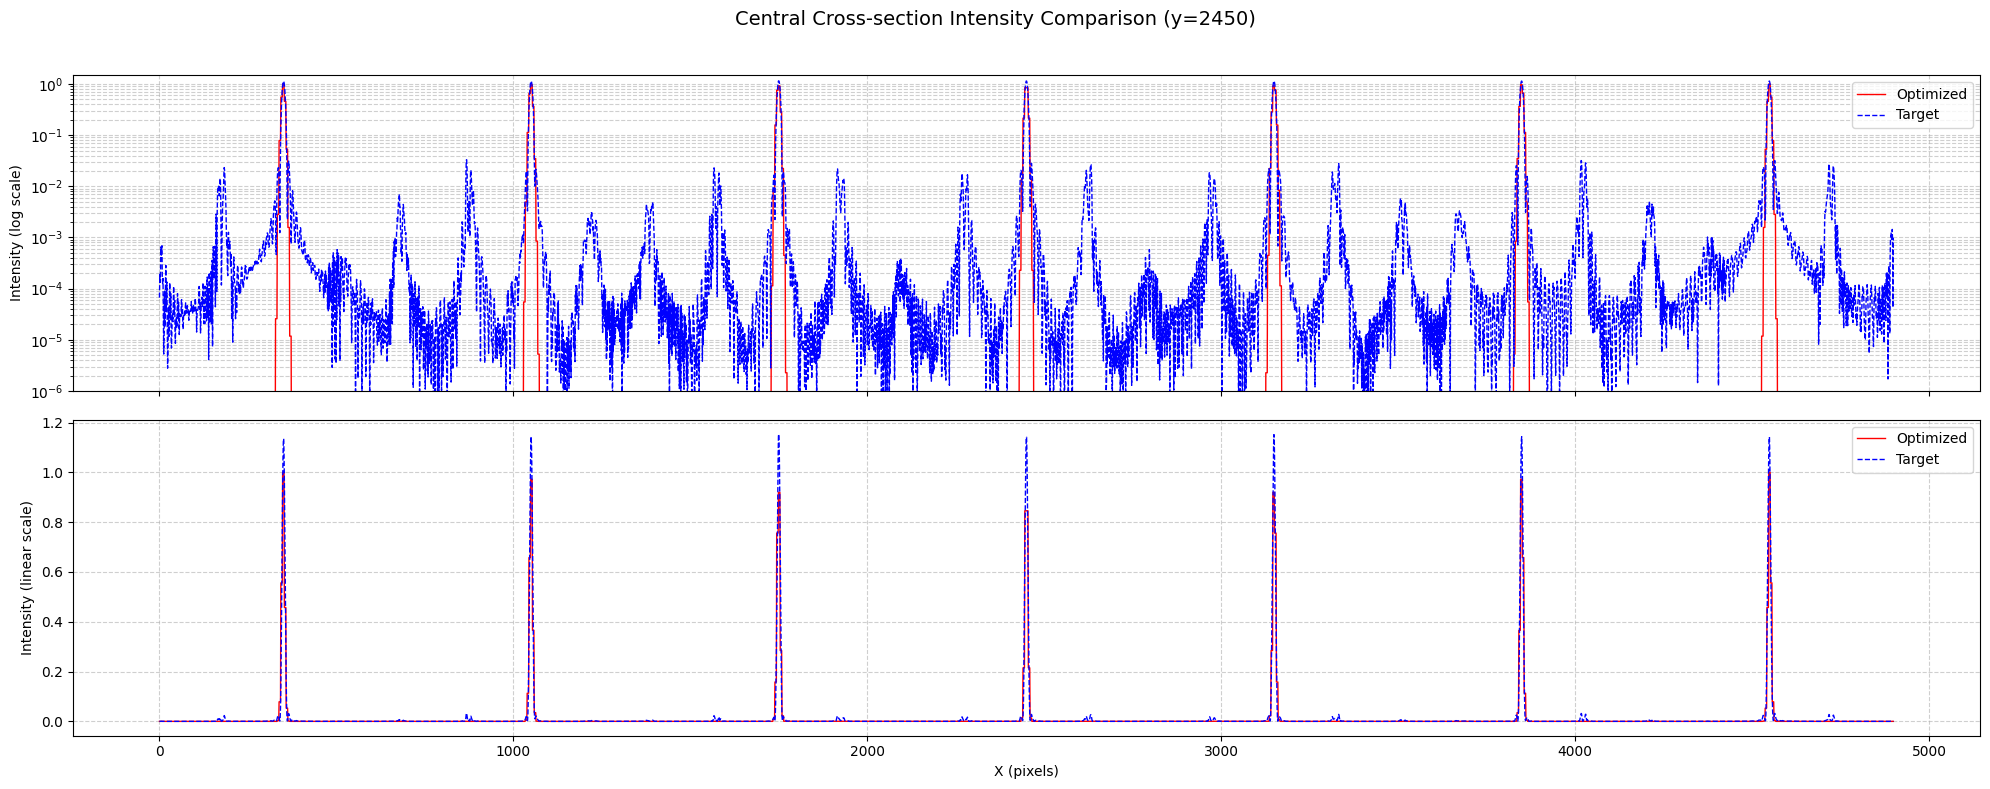

In [2]:
from visualization import plot_phase,plot_2d_comparisons, plot_cross_sections, plot_energy_distribution
# 可视化
plot_phase(Optimizer)
plot_2d_comparisons(Optimizer)
plot_cross_sections(Optimizer,upsampling=1.0)
plot_cross_sections(Optimizer,upsampling=3)
plot_cross_sections(Optimizer,upsampling=5)


Encircled energy radius used for calculation: 2.03 pixels


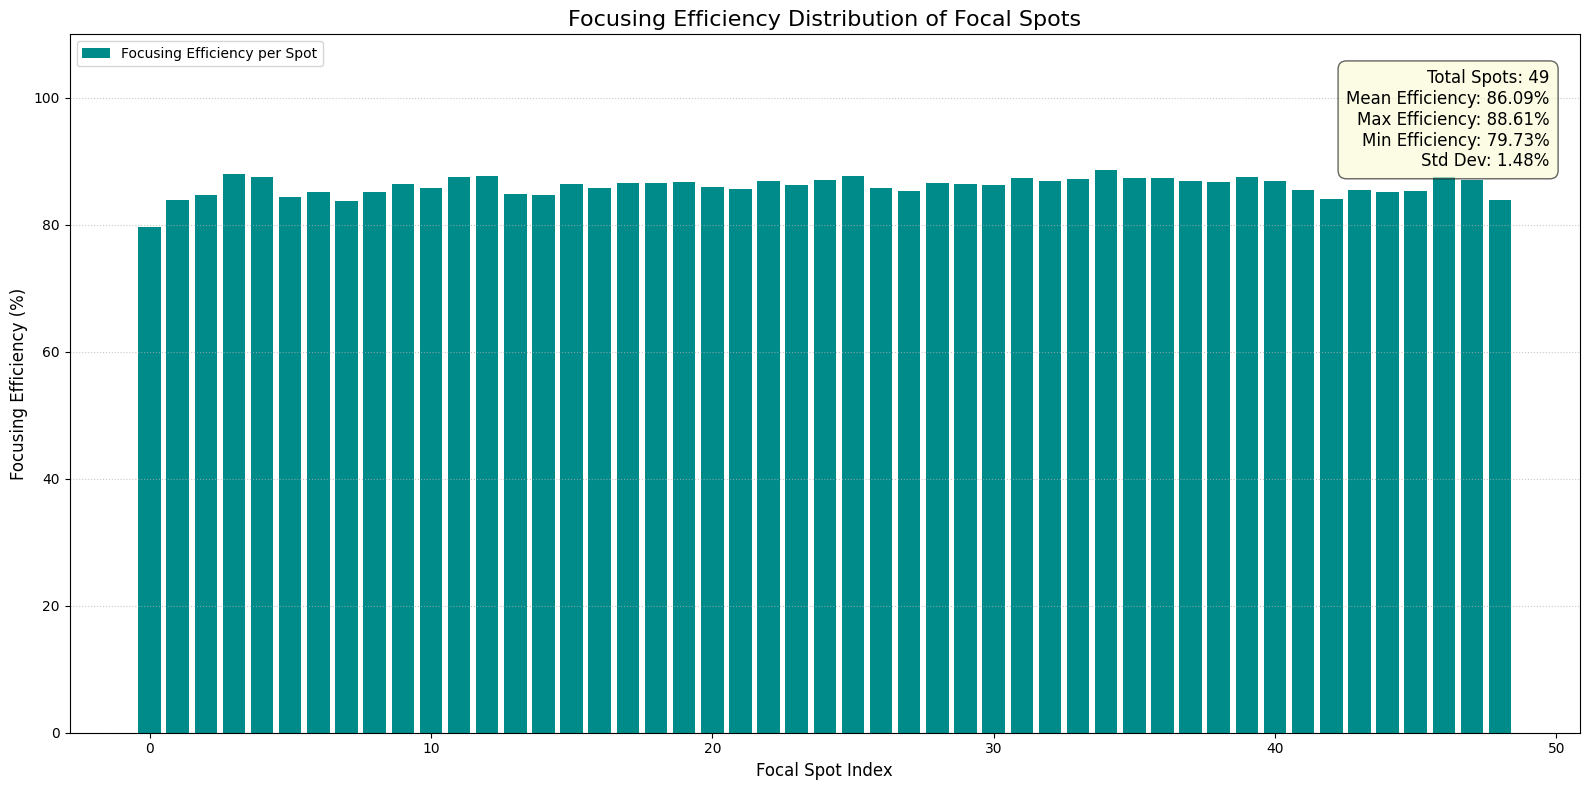

Encircled energy radius used for calculation: 6.10 pixels


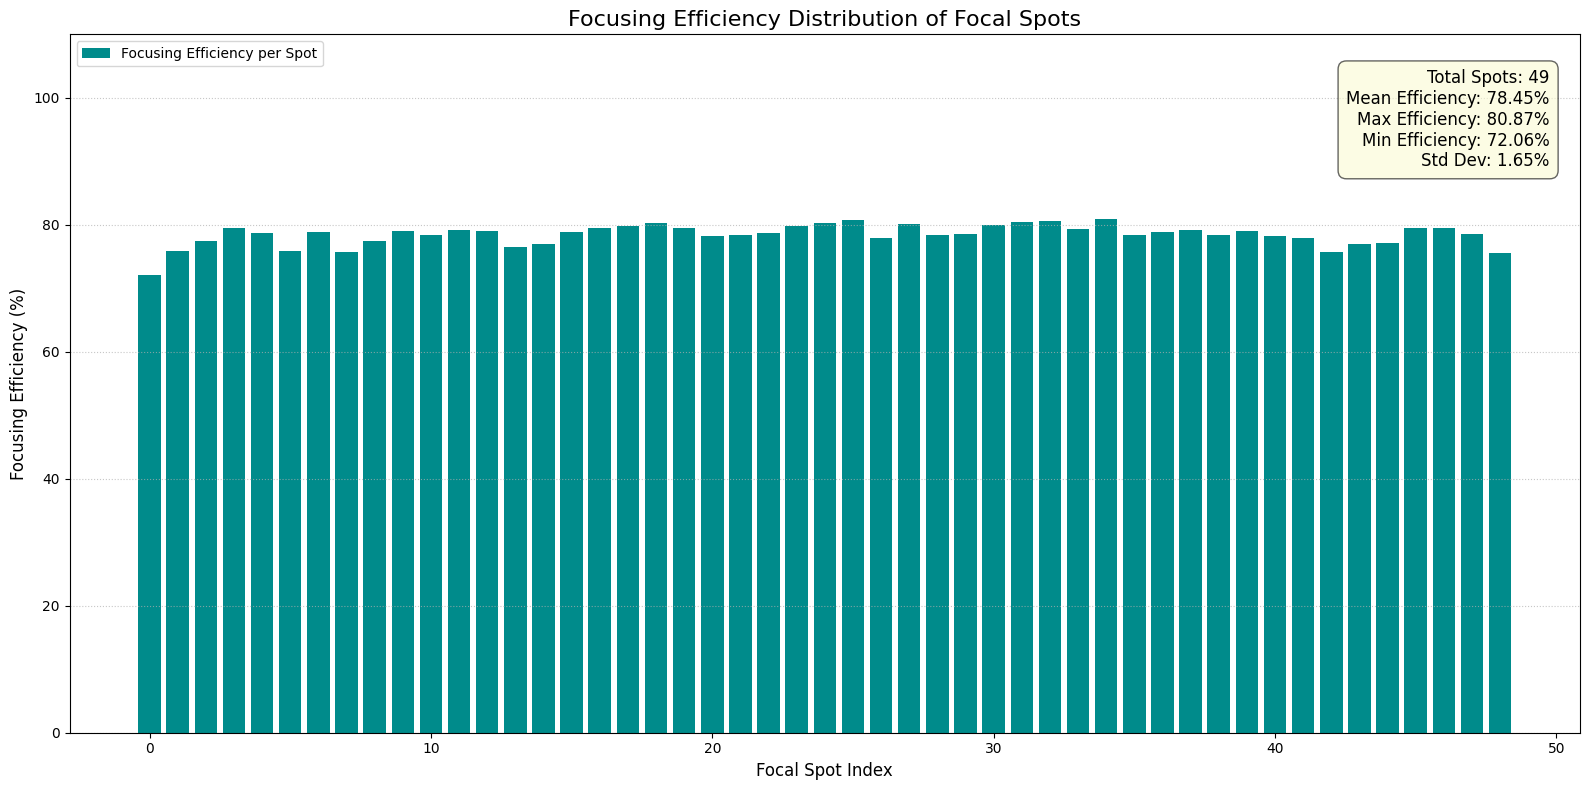

Encircled energy radius used for calculation: 10.17 pixels


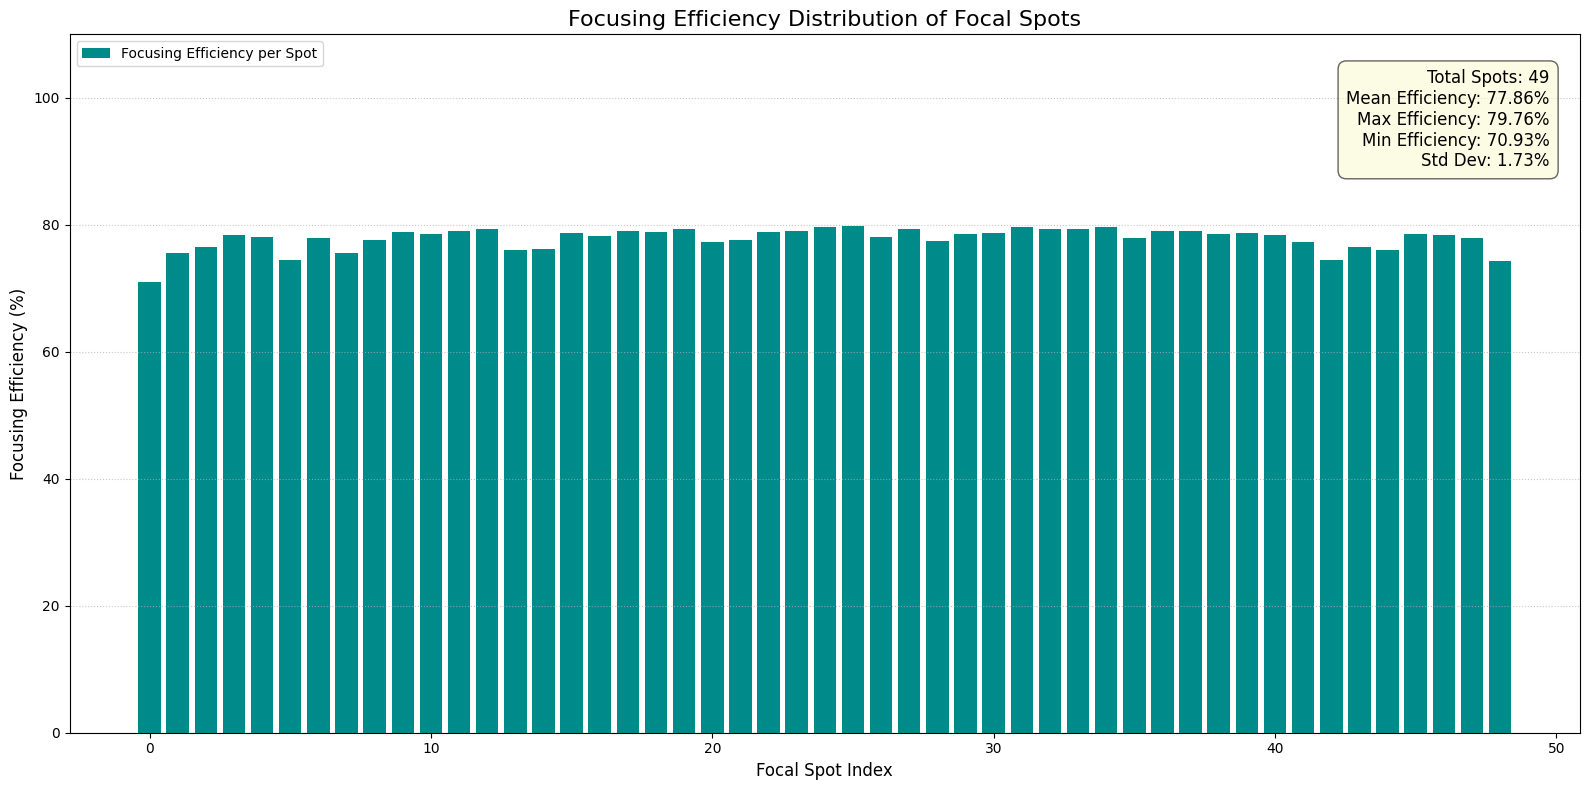

In [3]:
plot_energy_distribution(Optimizer,upsampling=1)
plot_energy_distribution(Optimizer,upsampling=3)
plot_energy_distribution(Optimizer,upsampling=5)